In [58]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [59]:
!pip install --upgrade pip setuptools wheel
!pip install catboost --no-cache-dir


Defaulting to user installation because normal site-packages is not writeable
  Using cached setuptools-80.1.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
Using cached setuptools-80.1.0-py3-none-any.whl (1.2 MB)
Using cached wheel-0.45.1-py3-none-any.whl (72 kB)

   ---------------------------------------- 0/2 [wheel]
   ---------------------------------------- 0/2 [wheel]
   ---------------------------------------- 0/2 [wheel]
   ---------------------------------------- 0/2 [wheel]
   ---------------------------------------- 0/2 [wheel]
   ---------------------------------------- 0/2 [wheel]
   ---------------------------------------- 0/2 [wheel]
   ---------------------------------------- 0/2 [wheel]
   ---------------------------------------- 0/2 [wheel]
   ---------------------------------------- 0/2 [wheel]
   -------------------- ------------------- 1/2 [setuptools]
   -------------------- ------------------- 1/2 [setuptools]


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable


In [60]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [61]:
!pip install scikit-learn 

Defaulting to user installation because normal site-packages is not writeable


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder


In [63]:
df=pd.read_csv('car.csv')

In [64]:
df.head(5)

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Driving_experience,Type_of_vehicle,Area_accident_occured,Road_surface_conditions,Light_conditions,Weather_conditions,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,1-2yr,Automobile,Residential areas,Dry,Daylight,Normal,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Above 10yr,Public (> 45 seats),Office areas,Dry,Daylight,Normal,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,1-2yr,Lorry (41?100Q),Recreational areas,Dry,Daylight,Normal,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,5-10yr,Public (> 45 seats),Office areas,Dry,Darkness - lights lit,Normal,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,2-5yr,NaN,Industrial areas,Dry,Darkness - lights lit,Normal,Overtaking,Slight Injury


In [65]:
df.shape

(12316, 12)

In [66]:
df.isnull().sum()

Time                         0
Day_of_week                  0
Age_band_of_driver           0
Sex_of_driver                0
Driving_experience         829
Type_of_vehicle            950
Area_accident_occured      239
Road_surface_conditions      0
Light_conditions             0
Weather_conditions           0
Cause_of_accident            0
Accident_severity            0
dtype: int64

In [67]:
df.describe()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Driving_experience,Type_of_vehicle,Area_accident_occured,Road_surface_conditions,Light_conditions,Weather_conditions,Cause_of_accident,Accident_severity
count,12316,12316,12316,12316,11487,11366,12077,12316,12316,12316,12316,12316
unique,1074,7,5,3,7,17,14,4,4,9,20,3
top,15:30:00,Friday,18-30,Male,5-10yr,Automobile,Other,Dry,Daylight,Normal,No distancing,Slight Injury
freq,120,2041,4271,11437,3363,3205,3819,9340,8798,10063,2263,10415


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Time                     12316 non-null  object
 1   Day_of_week              12316 non-null  object
 2   Age_band_of_driver       12316 non-null  object
 3   Sex_of_driver            12316 non-null  object
 4   Driving_experience       11487 non-null  object
 5   Type_of_vehicle          11366 non-null  object
 6   Area_accident_occured    12077 non-null  object
 7   Road_surface_conditions  12316 non-null  object
 8   Light_conditions         12316 non-null  object
 9   Weather_conditions       12316 non-null  object
 10  Cause_of_accident        12316 non-null  object
 11  Accident_severity        12316 non-null  object
dtypes: object(12)
memory usage: 1.1+ MB


In [19]:
df.dropna(subset=['Driving_experience','Type_of_vehicle','Area_accident_occured'],inplace=True)

In [20]:
df.isnull().sum()

Time                       0
Day_of_week                0
Age_band_of_driver         0
Sex_of_driver              0
Driving_experience         0
Type_of_vehicle            0
Area_accident_occured      0
Road_surface_conditions    0
Light_conditions           0
Weather_conditions         0
Cause_of_accident          0
Accident_severity          0
dtype: int64

In [21]:
duplicates=df[df.duplicated()]

In [22]:
df.drop(df[df.eq('Unknown').any(axis=1)].index, inplace=True)

In [23]:
# One-Hot Encoding 
df = pd.get_dummies(df, columns=['Sex_of_driver'])

In [24]:
df.head(5)

,Time,Day_of_week,Age_band_of_driver,Driving_experience,Type_of_vehicle,Area_accident_occured,Road_surface_conditions,Light_conditions,Weather_conditions,Cause_of_accident,Accident_severity,Sex_of_driver_Female,Sex_of_driver_Male
0,17:02:00,Monday,18-30,1-2yr,Automobile,Residential areas,Dry,Daylight,Normal,Moving Backward,Slight Injury,False,True
1,17:02:00,Monday,31-50,Above 10yr,Public (> 45 seats),Office areas,Dry,Daylight,Normal,Overtaking,Slight Injury,False,True
2,17:02:00,Monday,18-30,1-2yr,Lorry (41?100Q),Recreational areas,Dry,Daylight,Normal,Changing lane to the left,Serious Injury,False,True
3,1:06:00,Sunday,18-30,5-10yr,Public (> 45 seats),Office areas,Dry,Darkness - lights lit,Normal,Changing lane to the right,Slight Injury,False,True
6,17:30:00,Wednesday,18-30,2-5yr,Automobile,Residential areas,Dry,Daylight,Normal,Other,Slight Injury,False,True


In [25]:
# One-Hot Encoding
df = pd.get_dummies(df, columns=['Light_conditions'])

In [26]:
df.head(5)

,Time,Day_of_week,Age_band_of_driver,Driving_experience,Type_of_vehicle,Area_accident_occured,Road_surface_conditions,Weather_conditions,Cause_of_accident,Accident_severity,Sex_of_driver_Female,Sex_of_driver_Male,Light_conditions_Darkness - lights lit,Light_conditions_Darkness - lights unlit,Light_conditions_Darkness - no lighting,Light_conditions_Daylight
0,17:02:00,Monday,18-30,1-2yr,Automobile,Residential areas,Dry,Normal,Moving Backward,Slight Injury,False,True,False,False,False,True
1,17:02:00,Monday,31-50,Above 10yr,Public (> 45 seats),Office areas,Dry,Normal,Overtaking,Slight Injury,False,True,False,False,False,True
2,17:02:00,Monday,18-30,1-2yr,Lorry (41?100Q),Recreational areas,Dry,Normal,Changing lane to the left,Serious Injury,False,True,False,False,False,True
3,1:06:00,Sunday,18-30,5-10yr,Public (> 45 seats),Office areas,Dry,Normal,Changing lane to the right,Slight Injury,False,True,True,False,False,False
6,17:30:00,Wednesday,18-30,2-5yr,Automobile,Residential areas,Dry,Normal,Other,Slight Injury,False,True,False,False,False,True


In [27]:
#One-Hot Encoding
df = pd.get_dummies(df, columns=['Road_surface_conditions'])

In [28]:
df.head(5)

,Time,Day_of_week,Age_band_of_driver,Driving_experience,Type_of_vehicle,Area_accident_occured,Weather_conditions,Cause_of_accident,Accident_severity,Sex_of_driver_Female,Sex_of_driver_Male,Light_conditions_Darkness - lights lit,Light_conditions_Darkness - lights unlit,Light_conditions_Darkness - no lighting,Light_conditions_Daylight,Road_surface_conditions_Dry,Road_surface_conditions_Flood over 3cm. deep,Road_surface_conditions_Snow,Road_surface_conditions_Wet or damp
0,17:02:00,Monday,18-30,1-2yr,Automobile,Residential areas,Normal,Moving Backward,Slight Injury,False,True,False,False,False,True,True,False,False,False
1,17:02:00,Monday,31-50,Above 10yr,Public (> 45 seats),Office areas,Normal,Overtaking,Slight Injury,False,True,False,False,False,True,True,False,False,False
2,17:02:00,Monday,18-30,1-2yr,Lorry (41?100Q),Recreational areas,Normal,Changing lane to the left,Serious Injury,False,True,False,False,False,True,True,False,False,False
3,1:06:00,Sunday,18-30,5-10yr,Public (> 45 seats),Office areas,Normal,Changing lane to the right,Slight Injury,False,True,True,False,False,False,True,False,False,False
6,17:30:00,Wednesday,18-30,2-5yr,Automobile,Residential areas,Normal,Other,Slight Injury,False,True,False,False,False,True,True,False,False,False


In [29]:
df.head(10)

,Time,Day_of_week,Age_band_of_driver,Driving_experience,Type_of_vehicle,Area_accident_occured,Weather_conditions,Cause_of_accident,Accident_severity,Sex_of_driver_Female,Sex_of_driver_Male,Light_conditions_Darkness - lights lit,Light_conditions_Darkness - lights unlit,Light_conditions_Darkness - no lighting,Light_conditions_Daylight,Road_surface_conditions_Dry,Road_surface_conditions_Flood over 3cm. deep,Road_surface_conditions_Snow,Road_surface_conditions_Wet or damp
0,17:02:00,Monday,18-30,1-2yr,Automobile,Residential areas,Normal,Moving Backward,Slight Injury,False,True,False,False,False,True,True,False,False,False
1,17:02:00,Monday,31-50,Above 10yr,Public (> 45 seats),Office areas,Normal,Overtaking,Slight Injury,False,True,False,False,False,True,True,False,False,False
2,17:02:00,Monday,18-30,1-2yr,Lorry (41?100Q),Recreational areas,Normal,Changing lane to the left,Serious Injury,False,True,False,False,False,True,True,False,False,False
3,1:06:00,Sunday,18-30,5-10yr,Public (> 45 seats),Office areas,Normal,Changing lane to the right,Slight Injury,False,True,True,False,False,False,True,False,False,False
6,17:30:00,Wednesday,18-30,2-5yr,Automobile,Residential areas,Normal,Other,Slight Injury,False,True,False,False,False,True,True,False,False,False
7,17:20:00,Friday,18-30,2-5yr,Automobile,Residential areas,Normal,No priority to vehicle,Slight Injury,False,True,False,False,False,True,True,False,False,False
8,17:20:00,Friday,18-30,Above 10yr,Lorry (41?100Q),Industrial areas,Normal,Changing lane to the right,Slight Injury,False,True,False,False,False,True,True,False,False,False
9,17:20:00,Friday,18-30,1-2yr,Automobile,Residential areas,Normal,Moving Backward,Serious Injury,False,True,False,False,False,True,True,False,False,False
10,14:40:00,Saturday,18-30,1-2yr,Public (13?45 seats),Residential areas,Normal,Changing lane to the left,Serious Injury,False,True,False,False,False,True,True,False,False,False
11,14:40:00,Saturday,31-50,No Licence,Automobile,Office areas,Normal,No priority to pedestrian,Serious Injury,False,True,False,False,False,True,True,False,False,False


In [32]:
! pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\sulta\AppData\Local\Temp\ipykernel_2104\1375781217.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Accident_severity", palette="Set1")


Text(0, 0.5, 'Count')

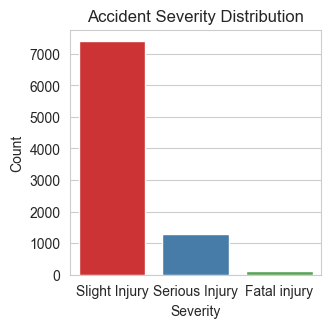

In [33]:
import seaborn as sns
sns.set_style("whitegrid")
plt.figure(figsize=(11,7))
plt.subplot(2, 3, 1)
sns.countplot(data=df, x="Accident_severity", palette="Set1")
plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")


C:\Users\sulta\AppData\Local\Temp\ipykernel_2104\4130900188.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Day_of_week", order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"], palette="Blues")


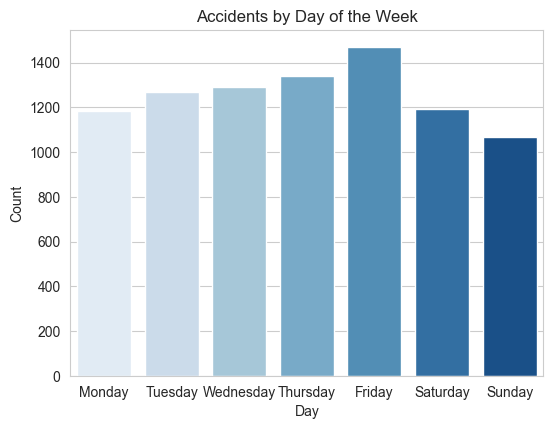

In [34]:
# 5. Time Analysis: Accidents by Day of the Week
plt.figure(figsize=(16,8))
sns.set_style("whitegrid")
plt.subplot(2, 3, 5)
sns.countplot(data=df, x="Day_of_week", order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"], palette="Blues")
plt.title("Accidents by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


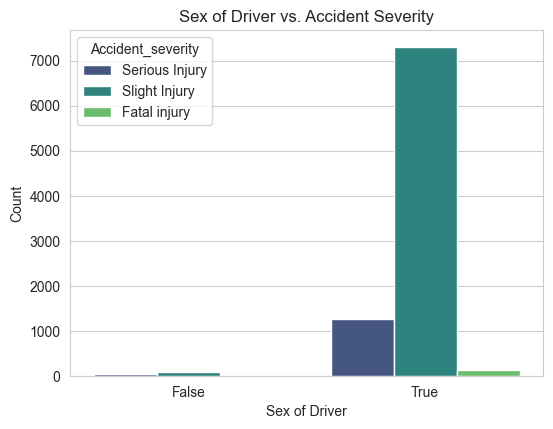

In [35]:
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")
plt.subplot(2, 3, 3)


sns.countplot(data=df, x="Sex_of_driver_Male", hue="Accident_severity", palette="viridis")

plt.title("Sex of Driver vs. Accident Severity")
plt.xlabel("Sex of Driver")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


C:\Users\sulta\AppData\Local\Temp\ipykernel_2104\3678826404.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Type_of_vehicle", order=df["Type_of_vehicle"].value_counts().index, palette="coolwarm")


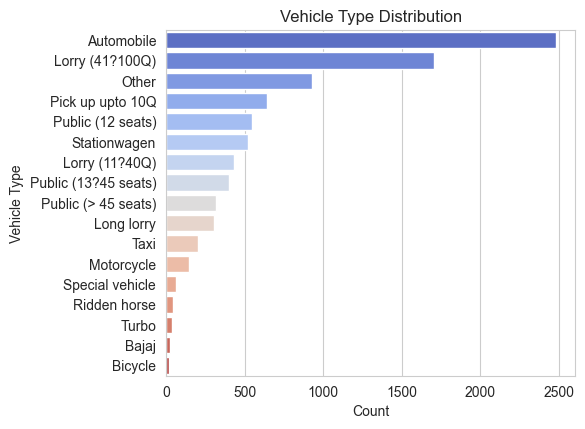

In [36]:
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")
plt.subplot(2, 3, 2)
sns.countplot(data=df, y="Type_of_vehicle", order=df["Type_of_vehicle"].value_counts().index, palette="coolwarm")
plt.title("Vehicle Type Distribution")
plt.xlabel("Count")
plt.ylabel("Vehicle Type")
plt.tight_layout()
plt.show()


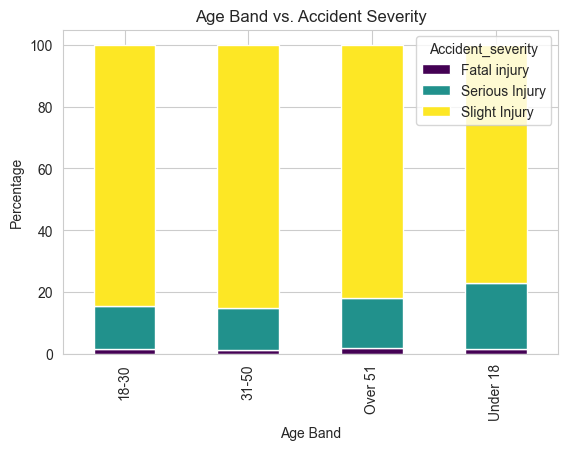

In [37]:
plt.figure(figsize=(16,8))
sns.set_style("whitegrid")
plt.subplot(2, 3, 4)
age_severity = pd.crosstab(df["Age_band_of_driver"], df["Accident_severity"], normalize="index") * 100
age_severity.plot(kind="bar", stacked=True, colormap="viridis", ax=plt.gca())
plt.title("Age Band vs. Accident Severity")
plt.xlabel("Age Band")
plt.ylabel("Percentage")
plt.tight_layout()
plt.show()


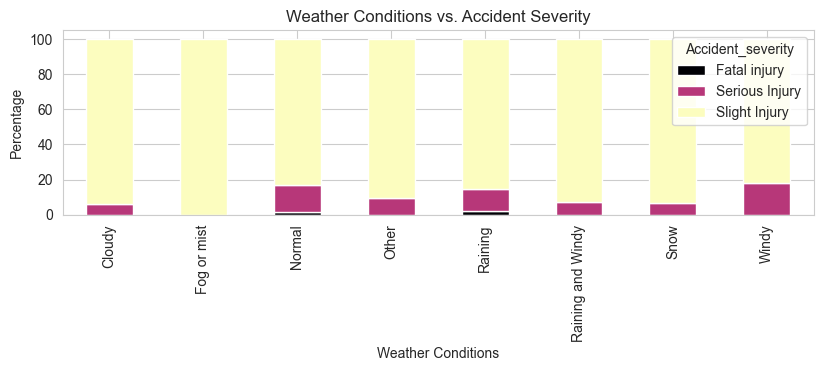

In [38]:
plt.figure(figsize=(16,8))
sns.set_style("whitegrid")
plt.subplot(3, 2, 6)
weather_severity = pd.crosstab(df["Weather_conditions"], df["Accident_severity"], normalize="index") * 100
weather_severity.plot(kind="bar", stacked=True, colormap="magma", ax=plt.gca())
plt.title("Weather Conditions vs. Accident Severity")
plt.xlabel("Weather Conditions")
plt.ylabel("Percentage")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18]),
 [Text(0, 0, 'Changing lane to the left'),
  Text(1, 0, 'Changing lane to the right'),
  Text(2, 0, 'Driving at high speed'),
  Text(3, 0, 'Driving carelessly'),
  Text(4, 0, 'Driving to the left'),
  Text(5, 0, 'Driving under the influence of drugs'),
  Text(6, 0, 'Drunk driving'),
  Text(7, 0, 'Getting off the vehicle improperly'),
  Text(8, 0, 'Improper parking'),
  Text(9, 0, 'Moving Backward'),
  Text(10, 0, 'No distancing'),
  Text(11, 0, 'No priority to pedestrian'),
  Text(12, 0, 'No priority to vehicle'),
  Text(13, 0, 'Other'),
  Text(14, 0, 'Overloading'),
  Text(15, 0, 'Overspeed'),
  Text(16, 0, 'Overtaking'),
  Text(17, 0, 'Overturning'),
  Text(18, 0, 'Turnover')])

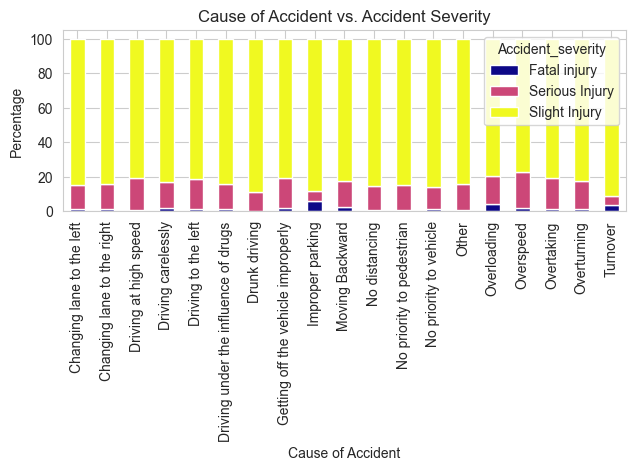

In [39]:
plt.figure(figsize=(16,8))
sns.set_style("whitegrid")
plt.subplot(3, 2, 5)
cause_severity = pd.crosstab(df["Cause_of_accident"], df["Accident_severity"], normalize="index") * 100
cause_severity.plot(kind="bar", stacked=True, colormap="plasma", ax=plt.gca())
plt.title("Cause of Accident vs. Accident Severity")
plt.xlabel("Cause of Accident")
plt.ylabel("Percentage")
plt.xticks(rotation=90)


Text(283.22222222222223, 0.5, 'Cause of Accident')

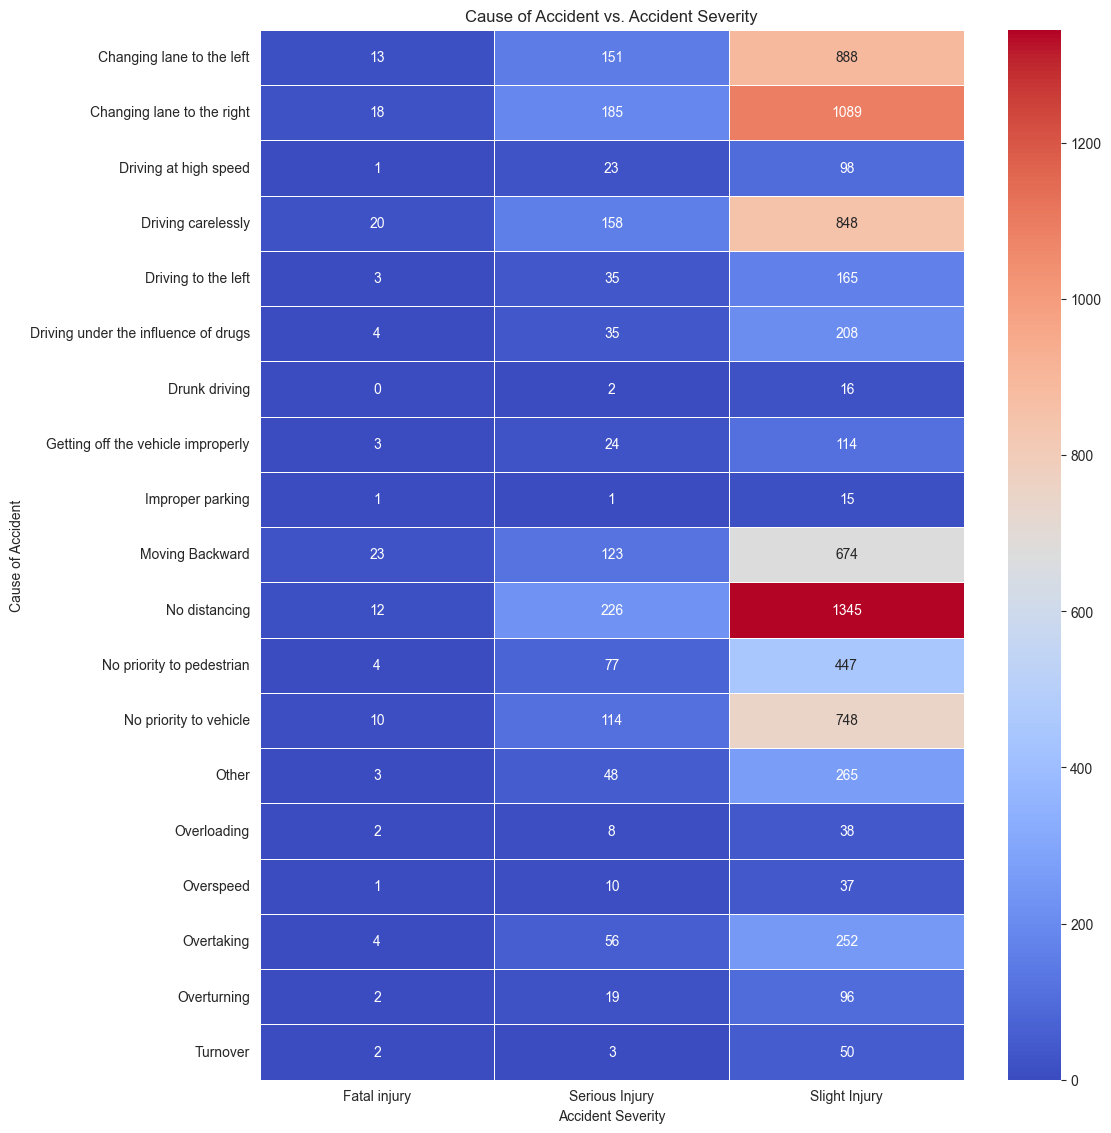

In [40]:
plt.figure(figsize=(25,30))
sns.set_style("whitegrid")
plt.subplot(2, 2, 3)
cause_severity = pd.crosstab(df["Cause_of_accident"], df["Accident_severity"])
sns.heatmap(cause_severity, cmap="coolwarm", annot=True, fmt="d", linewidths=0.5)
plt.title("Cause of Accident vs. Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Cause of Accident")


In [41]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['Accident_severity'])

In [42]:
Y = df['Accident_severity']                
X = df.drop(columns=['Accident_severity']) 

In [43]:
categorical_cols = X.select_dtypes(include='object').columns
print("Categorical columns to encode:", list(categorical_cols))

Categorical columns to encode: ['Time', 'Day_of_week', 'Age_band_of_driver', 'Driving_experience', 'Type_of_vehicle', 'Area_accident_occured', 'Weather_conditions', 'Cause_of_accident']


In [44]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [45]:
X_train, X_test, Y_train, Y_test = train_test_split(X_encoded, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42)

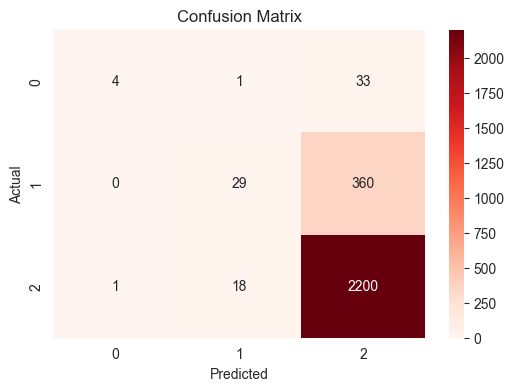

In [46]:
model = RandomForestClassifier()
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=np.unique(Y_test), yticklabels=np.unique(Y_test))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [47]:
dt_model = DecisionTreeClassifier(random_state=42)

In [48]:
dt_model.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=42)

In [49]:
estimated_acc = dt_model.score(X_test, Y_test)
print(f"Decision Tree Estimated Accuracy: {estimated_acc:.4f}")

Decision Tree Estimated Accuracy: 0.7925


In [50]:
rf_model = RandomForestClassifier(random_state=42)

In [51]:
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [52]:
estimated_acc2 = rf_model.score(X_test, Y_test)
print(f"random forest Estimated Accuracy: {estimated_acc2:.4f}")

random forest Estimated Accuracy: 0.8458


In [53]:
xgb=XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)
xgb.fit(X_train, Y_train)

C:\Users\sulta\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:183: UserWarning: [17:39:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [54]:
estimated_acc3 = xgb.score(X_test, Y_test)
print(f"Xgb Estimated Accuracy: {estimated_acc3:.4f}")

Xgb Estimated Accuracy: 0.8420


In [55]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier


In [56]:
joblib.dump(xgb, "accident_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")
joblib.dump(X_train.columns.tolist(), "columns.pkl")

['columns.pkl']

In [57]:
!pip install streamlit pandas


Defaulting to user installation because normal site-packages is not writeable


In [69]:
import joblib 

In [148]:
cat_model = CatBoostClassifier(verbose=0, random_state=42)

In [149]:
cat_model.fit(X_train, Y_train)

In [150]:
estimated_acc4 = cat_model.score(X_test, Y_test)
print(f"catboost Estimated Accuracy: {estimated_acc4:.4f}")

catboost Estimated Accuracy: 0.8435
